# Лабораторная работа: Метод ближайших соседей (KNN)

## Датасет: Chess Games (Lichess)
Датасет содержит информацию о ~20 000 шахматных партий с платформы Lichess.

**Источник:** [Kaggle — Chess Game Dataset](https://www.kaggle.com/datasets/datasnaek/chess)

**Задача:** классификация — предсказать победителя партии (white/black/draw)

**Признаки:**
| Признак | Описание |
|---|---|
| `rated` | Рейтинговая партия |
| `turns` | Количество ходов |
| `victory_status` | Способ завершения партии |
| `white_rating` | Рейтинг белых |
| `black_rating` | Рейтинг чёрных |
| `opening_ply` | Глубина дебюта |
| `winner` | Победитель (целевая переменная) |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, KFold,
                                     StratifiedKFold, cross_val_score)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from scipy.stats import randint

In [3]:
df = pd.read_csv("games.csv")

print(f"Размер: {df.shape}")
print(f"\nКолонки:\n{df.dtypes}")
print(f"\nПервые строки:")
df.head()

Размер: (20058, 16)

Колонки:
id                    str
rated                bool
created_at        float64
last_move_at      float64
turns               int64
victory_status        str
winner                str
increment_code        str
white_id              str
white_rating        int64
black_id              str
black_rating        int64
moves                 str
opening_eco           str
opening_name          str
opening_ply         int64
dtype: object

Первые строки:


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [4]:
print("=== Пропуски ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет!")

=== Пропуски ===
Пропусков нет!


In [5]:
# Отбираем нужные колонки
features = ['rated', 'turns', 'victory_status',
            'white_rating', 'black_rating', 'opening_ply']
target = 'winner'

df_model = df[features + [target]].copy()

# Кодирование бинарного признака rated (True/False → 1/0)
df_model['rated'] = df_model['rated'].astype(int)

# Label Encoding для victory_status
le_vs = LabelEncoder()
df_model['victory_status'] = le_vs.fit_transform(df_model['victory_status'])
print(f"victory_status классы: {list(enumerate(le_vs.classes_))}")

# Label Encoding для целевой переменной winner
le_w = LabelEncoder()
df_model['winner'] = le_w.fit_transform(df_model['winner'])
print(f"\nwinner классы: {list(enumerate(le_w.classes_))}")

print(f"\nРаспределение классов:")
print(df_model['winner'].value_counts())

df_model.head()

victory_status классы: [(0, 'draw'), (1, 'mate'), (2, 'outoftime'), (3, 'resign')]

winner классы: [(0, 'black'), (1, 'draw'), (2, 'white')]

Распределение классов:
winner
2    10001
0     9107
1      950
Name: count, dtype: int64


,rated,turns,victory_status,white_rating,black_rating,opening_ply,winner
0,0,13,2,1500,1191,5,2
1,1,16,3,1322,1261,4,0
2,1,61,1,1496,1500,3,2
3,1,61,1,1439,1454,3,2
4,1,95,1,1523,1469,5,2


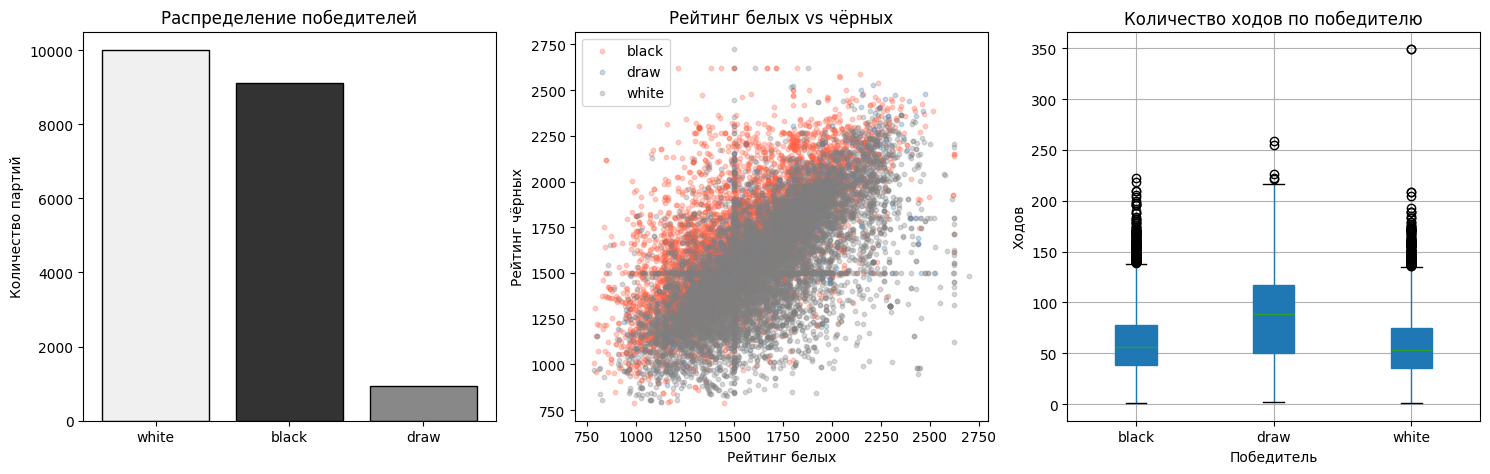

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Распределение победителей
winner_counts = df['winner'].value_counts()
axes[0].bar(winner_counts.index, winner_counts.values,
            color=['#f0f0f0', '#333333', '#888888'],
            edgecolor='black')
axes[0].set_title("Распределение победителей")
axes[0].set_ylabel("Количество партий")

# Рейтинг белых vs чёрных
for winner, color, label in zip([0,1,2],
                                  ['tomato','steelblue','gray'],
                                  le_w.classes_):
    mask = df_model['winner'] == winner
    axes[1].scatter(df_model[mask]['white_rating'],
                    df_model[mask]['black_rating'],
                    c=color, label=label, alpha=0.3, s=10)
axes[1].set_xlabel("Рейтинг белых")
axes[1].set_ylabel("Рейтинг чёрных")
axes[1].set_title("Рейтинг белых vs чёрных")
axes[1].legend()

# Количество ходов по победителю
df.boxplot(column='turns', by='winner', ax=axes[2],
           patch_artist=True)
axes[2].set_title("Количество ходов по победителю")
axes[2].set_xlabel("Победитель")
axes[2].set_ylabel("Ходов")
plt.suptitle("")

plt.tight_layout()
plt.savefig("chess_overview.png", dpi=150)
plt.show()

In [7]:
X = df_model[features].values
y = df_model['winner'].values

# Масштабирование (критично для KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train/test split 80/20 со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} образцов")
print(f"Test:  {X_test.shape[0]} образцов")
print(f"\nБаланс классов в train: {np.bincount(y_train)}")
print(f"Баланс классов в test:  {np.bincount(y_test)}")

Train: 16046 образцов
Test:  4012 образцов

Баланс классов в train: [7285  760 8001]
Баланс классов в test:  [1822  190 2000]


In [8]:
knn_base = KNeighborsClassifier(n_neighbors=7)
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
print(f"=== Базовая модель KNN (K=7) ===")
print(f"Accuracy: {acc_base:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_base,
                            target_names=le_w.classes_))

=== Базовая модель KNN (K=7) ===
Accuracy: 0.6284

Classification Report:
              precision    recall  f1-score   support

       black       0.60      0.56      0.58      1822
        draw       0.98      0.86      0.92       190
       white       0.62      0.67      0.64      2000

    accuracy                           0.63      4012
   macro avg       0.74      0.70      0.71      4012
weighted avg       0.63      0.63      0.63      4012



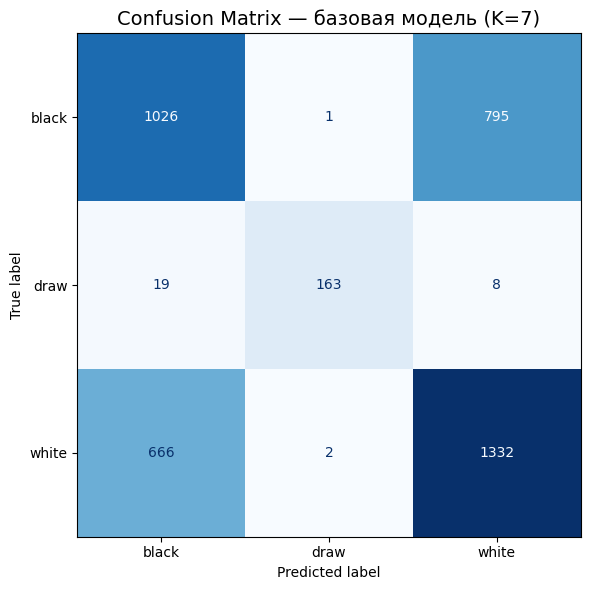

In [9]:
cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(cm, display_labels=le_w.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix — базовая модель (K=7)", fontsize=14)
plt.tight_layout()
plt.savefig("cm_base.png", dpi=150)
plt.show()

In [10]:
param_grid = {'n_neighbors': list(range(1, 31))}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_k_grid = grid_search.best_params_['n_neighbors']
best_score_grid = grid_search.best_score_

print(f"\n=== GridSearchCV (StratifiedKFold, 5 фолдов) ===")
print(f"Лучший K:    {best_k_grid}")
print(f"CV Accuracy: {best_score_grid:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== GridSearchCV (StratifiedKFold, 5 фолдов) ===
Лучший K:    13
CV Accuracy: 0.6430


In [11]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': randint(1, 31)},
    n_iter=30,
    cv=kf,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)

best_k_rand = random_search.best_params_['n_neighbors']
best_score_rand = random_search.best_score_

print(f"\n=== RandomizedSearchCV (KFold, 10 фолдов) ===")
print(f"Лучший K:    {best_k_rand}")
print(f"CV Accuracy: {best_score_rand:.4f}")

Fitting 10 folds for each of 30 candidates, totalling 300 fits

=== RandomizedSearchCV (KFold, 10 фолдов) ===
Лучший K:    29
CV Accuracy: 0.6451


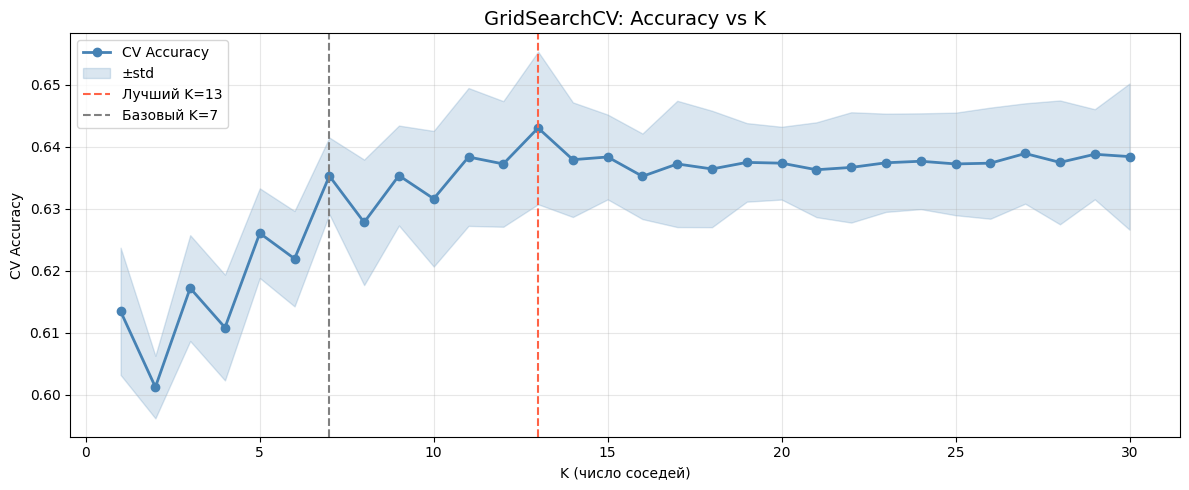

In [12]:
cv_results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(12, 5))
plt.plot(cv_results['param_n_neighbors'],
         cv_results['mean_test_score'],
         marker='o', color='steelblue', linewidth=2, label='CV Accuracy')
plt.fill_between(cv_results['param_n_neighbors'],
                 cv_results['mean_test_score'] - cv_results['std_test_score'],
                 cv_results['mean_test_score'] + cv_results['std_test_score'],
                 alpha=0.2, color='steelblue', label='±std')
plt.axvline(best_k_grid, color='tomato', linestyle='--',
            label=f'Лучший K={best_k_grid}')
plt.axvline(7, color='gray', linestyle='--', label='Базовый K=7')
plt.xlabel("K (число соседей)")
plt.ylabel("CV Accuracy")
plt.title("GridSearchCV: Accuracy vs K", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("gridsearch_results.png", dpi=150)
plt.show()

In [13]:
# Берём лучший K из GridSearchCV
knn_best = KNeighborsClassifier(n_neighbors=best_k_grid)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
print(f"=== Оптимальная модель KNN (K={best_k_grid}) ===")
print(f"Accuracy: {acc_best:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=le_w.classes_))

=== Оптимальная модель KNN (K=13) ===
Accuracy: 0.6301

Classification Report:
              precision    recall  f1-score   support

       black       0.60      0.56      0.58      1822
        draw       0.99      0.85      0.92       190
       white       0.62      0.68      0.65      2000

    accuracy                           0.63      4012
   macro avg       0.74      0.70      0.71      4012
weighted avg       0.63      0.63      0.63      4012



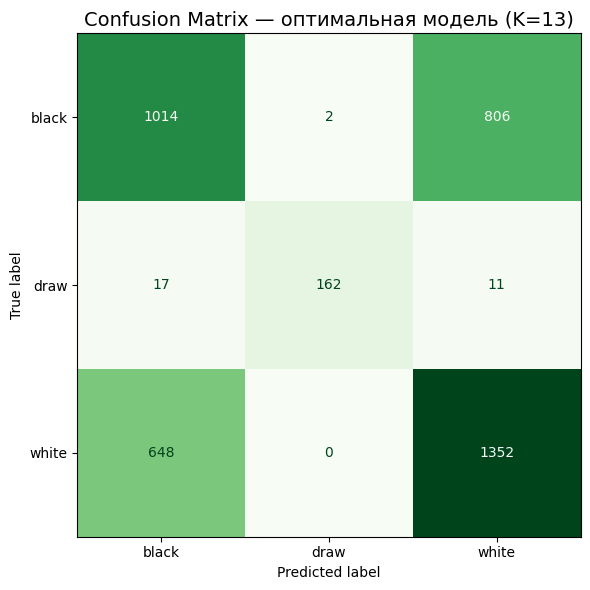

In [14]:
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(cm_best, display_labels=le_w.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp_best.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f"Confusion Matrix — оптимальная модель (K={best_k_grid})",
             fontsize=14)
plt.tight_layout()
plt.savefig("cm_best.png", dpi=150)
plt.show()

                   Модель  K  Test Accuracy  CV Accuracy
            Базовая (K=7)  7         0.6284       0.6353
      GridSearchCV (K=13) 13         0.6301       0.6430
RandomizedSearchCV (K=29) 29         0.6316       0.6451


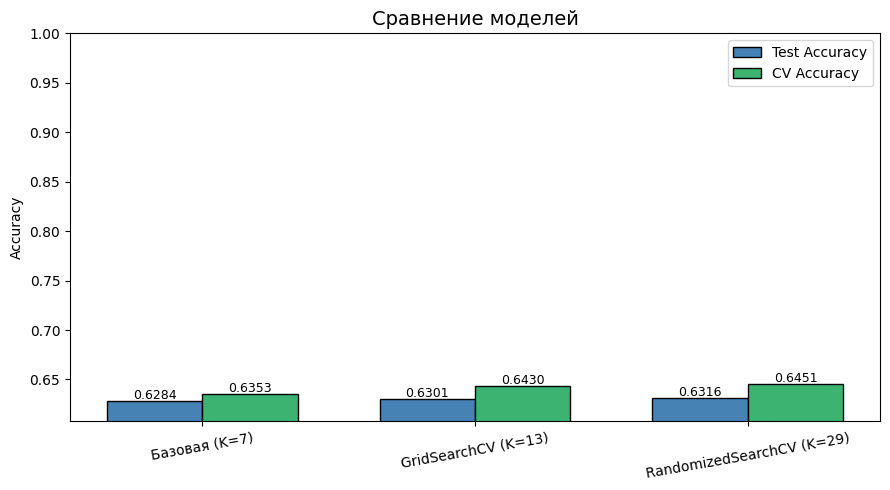

In [15]:
# Таблица сравнения
comparison = pd.DataFrame({
    'Модель': [f'Базовая (K=7)',
               f'GridSearchCV (K={best_k_grid})',
               f'RandomizedSearchCV (K={best_k_rand})'],
    'K': [7, best_k_grid, best_k_rand],
    'Test Accuracy': [acc_base, acc_best,
                      accuracy_score(y_test,
                          KNeighborsClassifier(n_neighbors=best_k_rand)
                          .fit(X_train, y_train).predict(X_test))],
    'CV Accuracy': [
        cross_val_score(KNeighborsClassifier(n_neighbors=7),
                        X_train, y_train, cv=skf).mean(),
        best_score_grid,
        best_score_rand
    ]
}).round(4)

print(comparison.to_string(index=False))

# Визуализация сравнения
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['Test Accuracy'],
               width, label='Test Accuracy',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison['CV Accuracy'],
               width, label='CV Accuracy',
               color='mediumseagreen', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Модель'], rotation=10)
ax.set_ylabel("Accuracy")
ax.set_title("Сравнение моделей", fontsize=14)
ax.set_ylim(min(comparison['Test Accuracy'].min(),
                comparison['CV Accuracy'].min()) - 0.02, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

Подбор K через GridSearchCV и RandomizedSearchCV дал небольшое улучшение качества модели
Accuracy ~63% объясняется природой задачи: рейтинги игроков близки в большинстве партий, что делает предсказание победителя объективно сложным
Основная проблема — дисбаланс классов: draw предсказывается значительно хуже white и black
KNN — не лучший алгоритм для данной задачи; более сложные модели (Random Forest, Gradient Boosting) вероятно дали бы accuracy 70%+